# Task 3

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import pandas as pd
from typing import List, Tuple
from scipy.spatial.transform import Rotation
import time
from tqdm.notebook import tqdm

from tools.pcd_tools import downsample_voxel, pcd_from_path, boundaries
from tools.plot_tools import plot_pcd, show_pcl, view_frames, plot_map_and_trajectories
from tools.analysis_tools import calc_error
from tools.dataset import FrameDataset
from tools.ndt_tools import NDT, Pose  # Import the provided NDT implementation


In [3]:
# Paths to dataset
DATASET_DIR = "./dataset"  # Update this to your dataset path
MAP_PATH = os.path.join(DATASET_DIR, "map.pcd")
GT_PATH = os.path.join(DATASET_DIR, "ground_truth.csv")
FRAMES_DIR = os.path.join(DATASET_DIR, "frames")

## Dataset

In [4]:
# set zero_z to True
zero_z = False

dataset = FrameDataset(FRAMES_DIR, GT_PATH, zero_z=zero_z)
map_pcd = pcd_from_path(MAP_PATH)

# convert map to 2d
if zero_z:
    map_pcd = np.c_[map_pcd[:, 0], map_pcd[:, 1], np.zeros(map_pcd.shape[0])]

print(f"Number of frames: {len(dataset)}")

# Get the first frame
pcd, gt_pos, gt_orientation = dataset[0]

Number of frames: 1014


## NDT Run

In [10]:
# Define parameters
voxel_size = 0.5  # Voxel size for downsampling
max_frames = 150   # Optional: limit number of frames to process
ndt_cell_size = 2.0
ndt_iterations = 100
num_frames = min(len(dataset), max_frames)
r = 2.5
zlims = [0, 7]

# Lists to track results
gt_positions = []
estimated_positions = []
computation_times = []
lateral_errors = []
yaw_errors = []

# Get the initial pose from ground truth to initialize
init_pcd, init_pos, init_orientation = dataset[0]
yaw = init_orientation[2]
current_pose = Pose(init_pos[0], init_pos[1], yaw)

# Create ICP object
ndt = NDT(ndt_cell_size, ndt_cell_size)
map_pcd_voxel, _ = downsample_voxel(map_pcd, voxel_size)
map_pcd_voxel_boundaries = boundaries(map_pcd_voxel, r, zlims=zlims)
ndt.set_input_cloud(map_pcd_voxel_boundaries)

i = 0
start_time = time.time()

# Get the current frame
pcd, gt_pos, gt_orientation = dataset[i]
gt_positions.append(gt_pos)

# Voxelize the point clouds to reduce complexity
pcd_voxel, _ = downsample_voxel(pcd, voxel_size)
pcd_voxel_boundaries = boundaries(pcd_voxel, r,zlims=zlims)

# Run NDT to align current scan with map
pose, _ = ndt.align(pcd_voxel_boundaries, current_pose, max_iterations=ndt_iterations, eps=0.001)

# Create transformation matrix from NDT result
estimated_position = np.array([pose.x, pose.y, 0.0])
estimated_orientation = np.array([0.0, 0.0, pose.yaw])
current_pose = pose

# Store estimated position
estimated_positions.append(estimated_position)

# Compute error
lateral_error, yaw_error = calc_error(gt_pos, gt_orientation, estimated_position, estimated_orientation)
lateral_errors.append(lateral_error)
yaw_errors.append(yaw_error)

# Compute execution time
execution_time = time.time() - start_time
computation_times.append(execution_time)

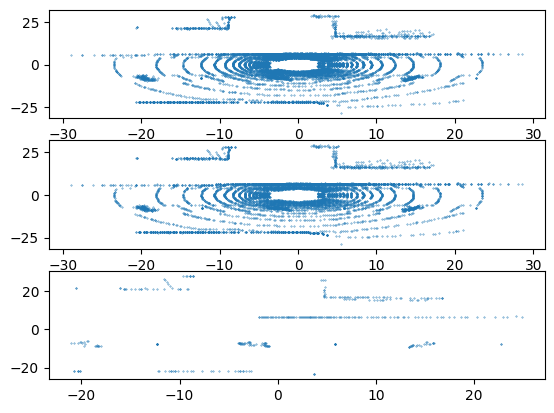

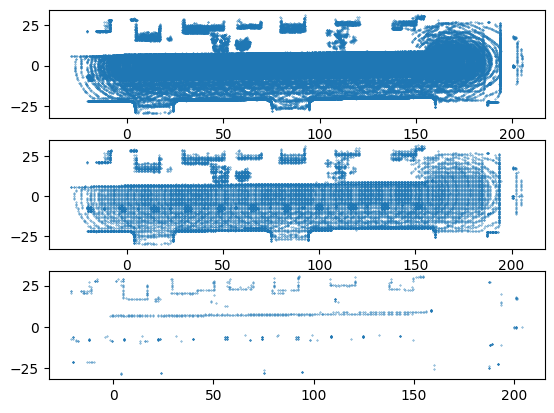

In [36]:
i = 0
zlims = [0, 4]
r = 3
voxel_size = 0.1

# Get the current frame
pcd, _, _ = dataset[i]
pcd_voxel, _ = downsample_voxel(pcd, voxel_size)

# filter out points with z within range
pcd_voxel_boundaries = boundaries(pcd_voxel, r, zlims=zlims)

fig, ax = plt.subplots(3,1)
plot_pcd(ax[0], pcd, s=0.1)
plot_pcd(ax[1], pcd_voxel, s=0.1)
plot_pcd(ax[2], pcd_voxel_boundaries, s=0.1)
plt.show()

map_pcd = pcd_from_path(MAP_PATH)
map_pcd_voxel, _ = downsample_voxel(map_pcd, voxel_size*8)
map_pcd_voxel_boundaries = boundaries(map_pcd_voxel, r, zlims=zlims)

fig, ax = plt.subplots(3,1)
plot_pcd(ax[0], map_pcd, s=0.1)
plot_pcd(ax[1], map_pcd_voxel, s=0.1)
plot_pcd(ax[2], map_pcd_voxel_boundaries, s=0.1)
plt.show()




In [ ]:
# Define parameters
voxel_size_scan = 0.25  # Voxel size for downsampling
voxel_size_map = 0.5
max_frames = 1500   # Optional: limit number of frames to process
ndt_cell_size = 3
ndt_iterations = 20
num_frames = min(len(dataset), max_frames)
r_scan = 1.5
r_map = 3
zlims = [0, 7]
ylim = None # (-30,30)
xlim = None # (-20, 200)

# Lists to track results
gt_positions = []
estimated_positions = []
computation_times = []
lateral_errors = []
yaw_errors = []

# Get the initial pose from ground truth to initialize
init_pcd, init_pos, init_orientation = dataset[0]
yaw = init_orientation[2]
current_pose = Pose(init_pos[0], init_pos[1], yaw)

# Process frames
pbar = tqdm(range(0, num_frames), desc="Processing frames", leave=True)

# Create ICP object
ndt = NDT(ndt_cell_size, ndt_cell_size, ylim=ylim, xlim=xlim)
map_pcd_voxel, _ = downsample_voxel(map_pcd, voxel_size_map)
map_pcd_voxel_boundaries = boundaries(map_pcd_voxel, r_map, zlims=zlims)
ndt.set_input_cloud(map_pcd_voxel_boundaries)

for i in pbar:
    start_time = time.time()

    # Get the current frame
    pcd, gt_pos, gt_orientation = dataset[i]
    gt_positions.append(gt_pos)
    
    # Voxelize the point clouds to reduce complexity
    pcd_voxel, _ = downsample_voxel(pcd, voxel_size_scan)
    pcd_voxel_boundaries = boundaries(pcd_voxel, r_scan ,zlims=zlims)

    # Run NDT to align current scan with map
    pose, _ = ndt.align(pcd_voxel_boundaries, current_pose, max_iterations=ndt_iterations, eps=0.001)
    
    # Create transformation matrix from NDT result
    estimated_position = np.array([pose.x, pose.y, 0.0])
    estimated_orientation = np.array([0.0, 0.0, pose.yaw])
    current_pose = pose
    
    # Store estimated position
    estimated_positions.append(estimated_position)
    
    # Compute error
    norm_error = np.linalg.norm(estimated_position - gt_pos)
    lateral_error, yaw_error = calc_error(gt_pos, gt_orientation, estimated_position, estimated_orientation)
    lateral_errors.append(lateral_error)
    yaw_errors.append(yaw_error)
    
    # Compute execution time
    execution_time = time.time() - start_time
    computation_times.append(execution_time)
    
    # Update progress bar with current error
    pbar.set_postfix({"Norm Error": f"{norm_error:.2f}m", "Lateral Error": f"{lateral_error:.2f}m", f"Yaw Error": f"{yaw_error:.2f}deg", "Time": f"{execution_time:.2f}s"})

Processing frames:   0%|          | 0/1014 [00:00<?, ?it/s]

In [41]:
print(map_pcd_voxel_boundaries.shape)
print(pcd_voxel_boundaries.shape)

(2184, 3)
(725, 3)


## Analysis

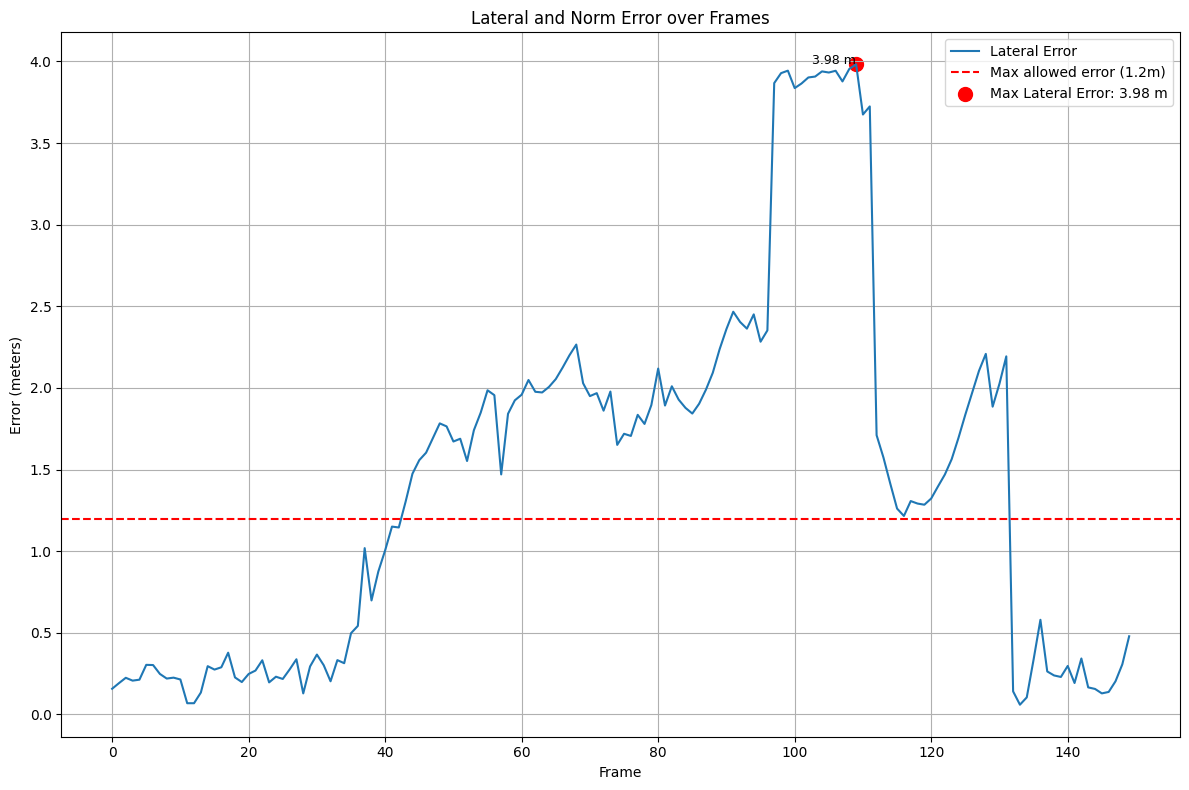

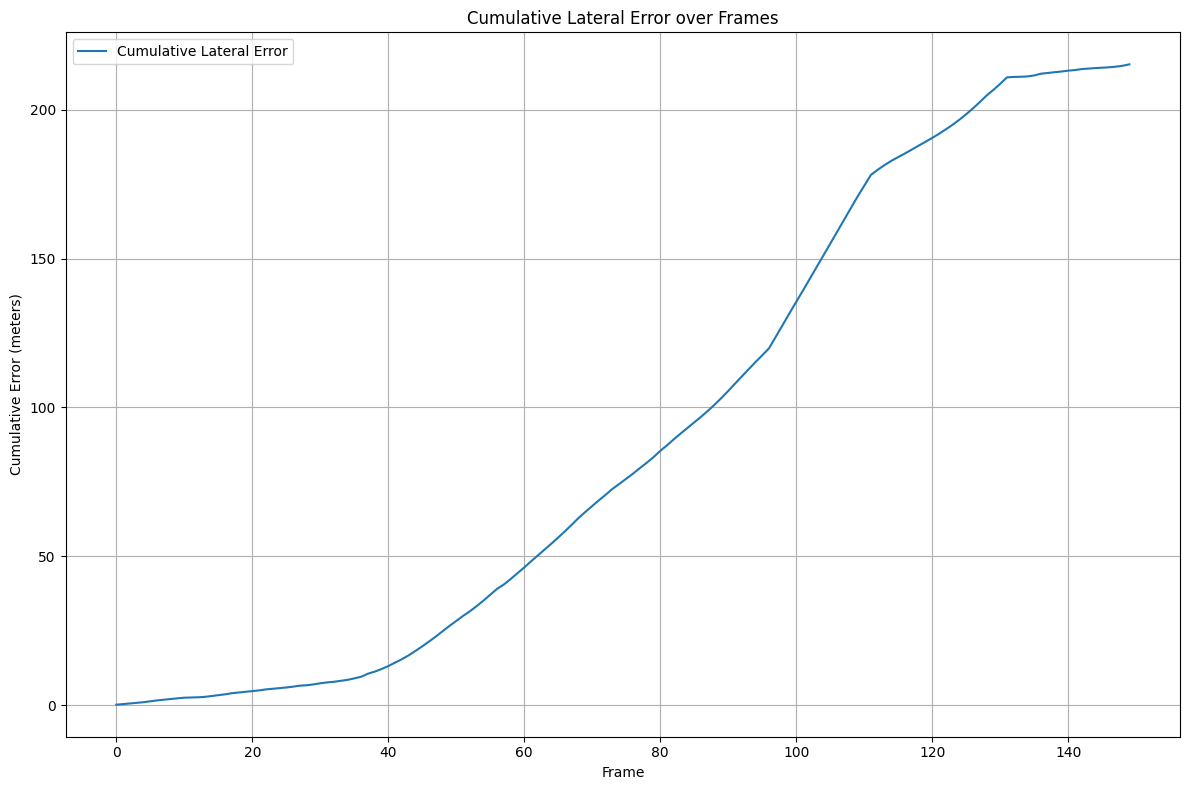

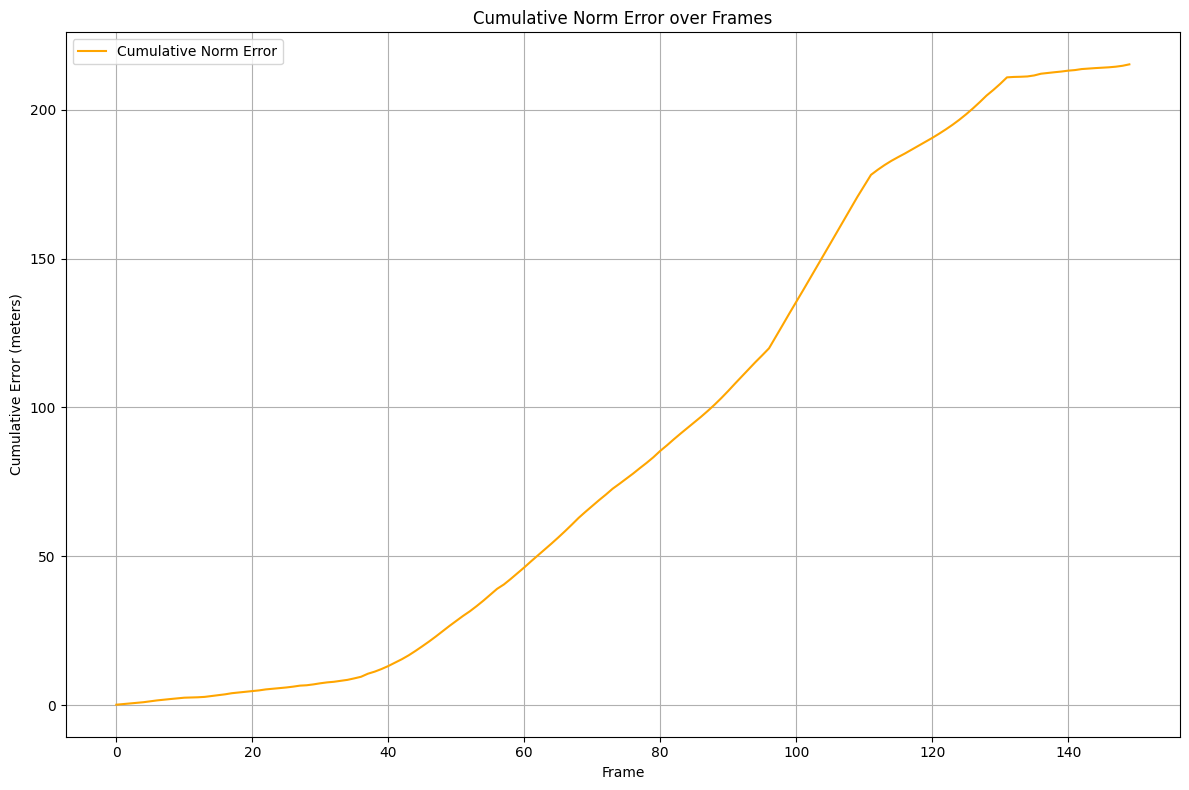

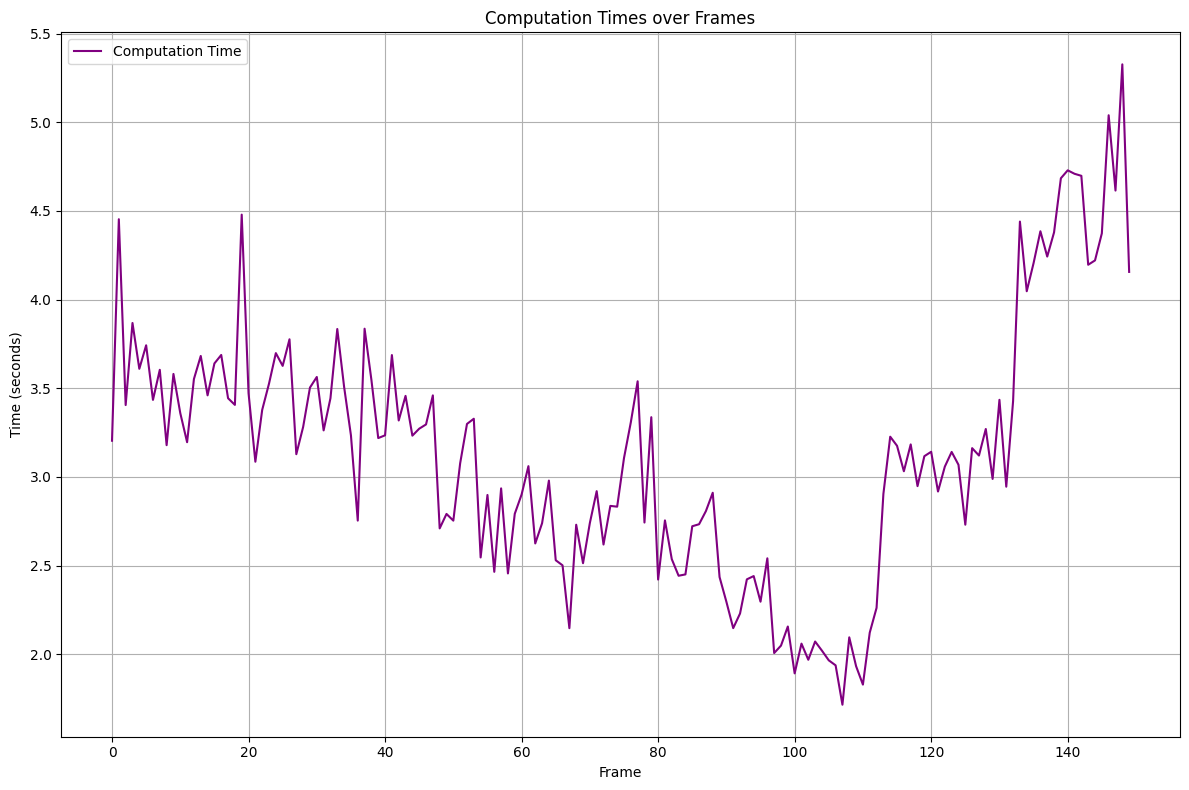

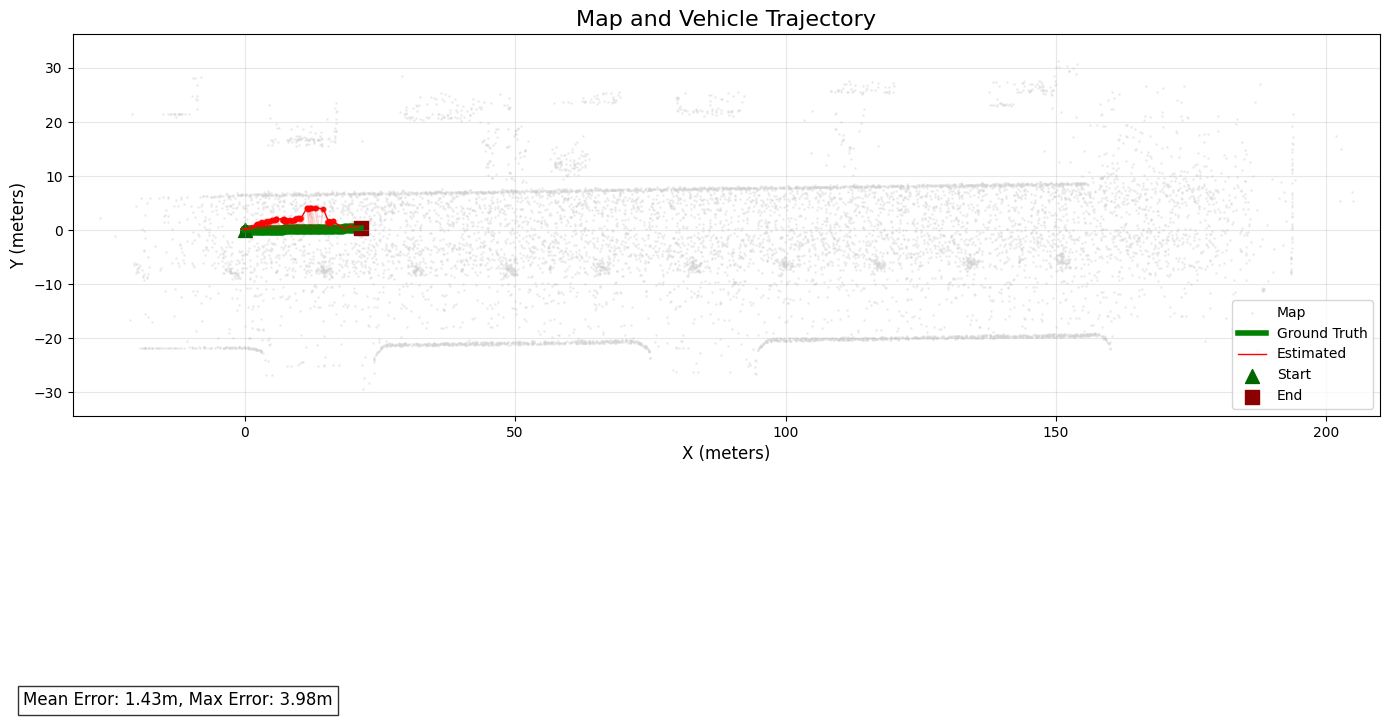

In [42]:
# Convert lists to numpy arrays
gt_positions = np.array(gt_positions)
estimated_positions = np.array(estimated_positions)
computation_times = np.array(computation_times)
lateral_errors = np.array(lateral_errors)
yaw_errors = np.array(yaw_errors)

max_lateral_error = np.max(lateral_errors)
max_norm_error = np.max(np.linalg.norm(estimated_positions - gt_positions, axis=1))

# Plot results
plt.figure(figsize=(12, 8))

# Plot lateral and norm error over frames in the same plot
plt.plot(lateral_errors, label='Lateral Error')
plt.axhline(y=1.2, color='r', linestyle='--', label='Max allowed error (1.2m)')

# Mark the position of the max lateral error
max_error_index = np.argmax(lateral_errors)
plt.scatter(max_error_index, max_lateral_error, color='red', s=100, label=f'Max Lateral Error: {max_lateral_error:.2f} m')
plt.text(max_error_index, max_lateral_error, f'{max_lateral_error:.2f} m', fontsize=9, ha='right')

plt.title("Lateral and Norm Error over Frames")
plt.xlabel("Frame")
plt.ylabel("Error (meters)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Calculate cumulative errors
cumulative_lateral_errors = np.cumsum(lateral_errors)
cumulative_norm_errors = np.cumsum(np.linalg.norm(estimated_positions - gt_positions, axis=1))

# Plot cumulative lateral errors
plt.figure(figsize=(12, 8))
plt.plot(cumulative_lateral_errors, label='Cumulative Lateral Error')
plt.title("Cumulative Lateral Error over Frames")
plt.xlabel("Frame")
plt.ylabel("Cumulative Error (meters)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot cumulative norm errors
plt.figure(figsize=(12, 8))
plt.plot(cumulative_norm_errors, label='Cumulative Norm Error', color='orange')
plt.title("Cumulative Norm Error over Frames")
plt.xlabel("Frame")
plt.ylabel("Cumulative Error (meters)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot computation times across frames
plt.figure(figsize=(12, 8))
plt.plot(computation_times, label='Computation Time', color='purple')
plt.title("Computation Times over Frames")
plt.xlabel("Frame")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plot_map_and_trajectories(map_pcd, gt_positions, estimated_positions)